# 10 — Dijagnoza skrivenog stilskog rizika hijerarhijskih alokatora

Faza 2, taskovi **F2.1–F2.4**. Cilj: izmjeriti **skrivene stilske izloženosti**
korelacijskih HRP/HERC/NCO i testirati **H1** — nasljeđuju li korelacijski
hijerarhijski alokatori RMW/CMA nagib min-vara (mehanizam: inverzno-varijančna
alokacija favorizira niskovolatilne grane; Scherer 2011, Novy-Marx 2014).

Ulazi su **zamrznuti paneli prinosa iz Faze 1** (nikakva izmjena alokatora,
prostora ni benchmarka):

- benchmark obitelj + `factor_neutral_eε` (`05_port_returns_panel_extended.csv`),
- korelacijski hijerarhijski alokatori `hrp_corr_single`, `hrp_corr_ward`,
  `herc_corr`, `nco_corr` (`09_port_returns_panel_hierarchical.csv`).

Obje HRP varijante atribuiraju se radi potpunosti; `hrp_corr_ward` je nositelj
kontrolirane usporedbe prostora u Fazi 3 (korekcija K1).


In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

logging.basicConfig(level=logging.WARNING, format="%(asctime)s %(levelname)s %(message)s")

from src.evaluation import (
    FACTOR_COLUMNS,
    annualized_vol,
    block_bootstrap_diff,
    block_bootstrap_metric,
    factor_attribution_full_sample,
    factor_attribution_per_window,
    style_concentration,
)
from src.utils import (
    BLOCK_SIZE_MONTHS,
    FIGURES_DIR,
    N_BOOTSTRAP_RETURNS,
    PROCESSED_DATA_DIR,
    RANDOM_SEED,
    TABLES_DIR,
    ensure_dirs,
    set_seed,
)

ensure_dirs()
set_seed()


In [2]:
factors = pd.read_csv(
    PROCESSED_DATA_DIR / "factors.csv", index_col=0, parse_dates=True
)
factor_exposures = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")

# Zamrznuti paneli prinosa iz Faze 1.
benchmark_panel = pd.read_csv(
    TABLES_DIR / "05_port_returns_panel_extended.csv", index_col=0, parse_dates=True
)
hierarchical_panel = pd.read_csv(
    TABLES_DIR / "09_port_returns_panel_hierarchical.csv", index_col=0, parse_dates=True
)
combined = pd.concat([benchmark_panel, hierarchical_panel], axis=1)

# Dugi paneli težina za mehaničku dijagnostiku (F2.3).
weights_core = pd.read_csv(TABLES_DIR / "weights_panel.csv")           # equal_weight, min_var
weights_hier = pd.read_csv(TABLES_DIR / "09_weights_panel_hierarchical.csv")
weights_all = pd.concat([weights_core, weights_hier], ignore_index=True)

HIERARCHICAL = ["hrp_corr_single", "hrp_corr_ward", "herc_corr", "nco_corr"]
print("Spojeni panel:", combined.shape, "| stupci:", combined.columns.tolist())
print("Mjeseci:", combined.index.min().date(), "->", combined.index.max().date())


Spojeni panel: (156, 10) | stupci: ['equal_weight', 'min_var', 'factor_neutral_e0', 'factor_neutral_e0.05', 'factor_neutral_e0.1', 'factor_neutral_e0.15', 'hrp_corr_single', 'hrp_corr_ward', 'herc_corr', 'nco_corr']
Mjeseci: 2013-01-31 -> 2025-12-31


## 10.1 F2.1 — FF5 atribucija hijerarhijskih alokatora

`factor_attribution_full_sample` (jedan redak po portfelju na cijelom OOS nizu) i
`factor_attribution_per_window` (jedan redak po testnoj godini) primjenjuju se na
spojeni panel: benchmarki + `factor_neutral_eε` obitelj + četiri korelacijska
hijerarhijska alokatora. Svaki redak nosi α, pet beta, R², `style_concentration`
i `n_months`.


In [3]:
attribution_full = factor_attribution_full_sample(combined, factors)
attribution_full.to_csv(TABLES_DIR / "10_attribution_full_sample.csv", index=False)

attribution_per_year = factor_attribution_per_window(combined, factors)
attribution_per_year.to_csv(TABLES_DIR / "10_attribution_per_year.csv", index=False)

# Kriterij F2.1: alfa, 5 beta, R2, style_concentration, n_months; pokriveni svi alokatori.
required_cols = {
    "alpha", "beta_mkt", "beta_smb", "beta_hml", "beta_rmw", "beta_cma",
    "r_squared", "style_concentration", "n_months",
}
assert required_cols.issubset(attribution_full.columns)
assert required_cols.issubset(attribution_per_year.columns)
covered = set(attribution_full["portfolio"])
for name in combined.columns:
    assert name in covered, f"Alokator nije pokriven atribucijom: {name}"

print("Pokriveni alokatori (puni uzorak):", len(attribution_full))
print("Redaka po testnoj godini:", len(attribution_per_year))
attribution_full[
    ["portfolio", "beta_rmw", "beta_cma", "style_concentration", "r_squared", "n_months"]
].round(4)


Pokriveni alokatori (puni uzorak): 10
Redaka po testnoj godini: 130


,portfolio,beta_rmw,beta_cma,style_concentration,r_squared,n_months
0,equal_weight,0.1699,0.0742,0.5948,0.9589,156
1,factor_neutral_e0,0.1437,0.3180,0.5255,0.7885,156
2,factor_neutral_e0.05,0.1767,0.3297,0.5906,0.7632,156
3,factor_neutral_e0.1,0.2112,0.3569,0.6688,0.7473,156
4,factor_neutral_e0.15,0.2385,0.3703,0.7261,0.7371,156
5,herc_corr,0.2348,0.2545,0.5739,0.6651,156
6,hrp_corr_single,0.2395,0.1801,0.5493,0.9025,156
7,hrp_corr_ward,0.2521,0.1775,0.5683,0.8928,156
8,min_var,0.2763,0.3879,0.7761,0.7069,156
9,nco_corr,0.3170,0.3749,0.7982,0.7251,156


## 10.2 F2.2 — Blok-bootstrap intervali i parne razlike (test H1)

Dva izlaza (sjeme, broj uzoraka i veličina bloka iz `config.yaml`):

1. **`10_bootstrap_ci.csv`** — `block_bootstrap_metric` daje 95 % CI
   `style_concentration` za svaki alokator. `p_two_sided` testira `H0: razina = 0`
   (koncentracija stila je nenegativna pa je p tu trivijalno mali — stupac postoji
   radi jedinstvene sheme s tablicom parnih razlika).
2. **`10_paired_diffs_vs_minvar.csv`** — `block_bootstrap_diff` (zajedničko
   uzorkovanje) za svaki korelacijski hijerarhijski alokator **naspram `min_var`
   i naspram `equal_weight`**, za `style_concentration` i `annualized_vol`.

**Pravilo odluke H1:** nagib je *naslijeđen* ako je razlika koncentracije stila
naspram `min_var` ≈ 0 (CI obuhvaća nulu) ili joj je točka pozitivna, **a** razlika
naspram `equal_weight` (1/N) značajno pozitivna.


In [4]:
FCOLS = list(FACTOR_COLUMNS) + ["RF"]  # Mkt-RF, SMB, HML, RMW, CMA, RF


def _style_conc_panel(panel):
    return style_concentration(panel["y"], panel[FCOLS])


def _sc(series, fac):
    return style_concentration(series, fac)


def _vol(series):
    return annualized_vol(series)


allocators_ci = ["equal_weight", "min_var"] + HIERARCHICAL
ci_rows = []
for name in allocators_ci:
    panel = pd.concat(
        [combined[name].rename("y"), factors], axis=1, join="inner"
    ).dropna()
    r = block_bootstrap_metric(
        panel, _style_conc_panel, n_bootstraps=N_BOOTSTRAP_RETURNS,
        block_size=BLOCK_SIZE_MONTHS, seed=RANDOM_SEED,
    )
    samples = r["samples"]
    p_two_sided = float(2 * min((samples <= 0).mean(), (samples >= 0).mean()))
    ci_rows.append(
        {
            "portfolio": name, "metric": "style_concentration",
            "point": r["point"], "ci_low": r["ci_low"], "ci_high": r["ci_high"],
            "p_two_sided": p_two_sided,
        }
    )
bootstrap_ci = pd.DataFrame(
    ci_rows,
    columns=["portfolio", "metric", "point", "ci_low", "ci_high", "p_two_sided"],
)
bootstrap_ci.to_csv(TABLES_DIR / "10_bootstrap_ci.csv", index=False)
print(bootstrap_ci.round(4).to_string(index=False))


      portfolio              metric  point  ci_low  ci_high  p_two_sided
   equal_weight style_concentration 0.5948  0.4537   0.7215          0.0
        min_var style_concentration 0.7761  0.4915   1.3410          0.0
hrp_corr_single style_concentration 0.5493  0.3758   0.8330          0.0
  hrp_corr_ward style_concentration 0.5683  0.4106   0.8131          0.0
      herc_corr style_concentration 0.5739  0.4055   1.2082          0.0
       nco_corr style_concentration 0.7982  0.6273   1.2808          0.0


In [5]:
diff_rows = []
for compared_to in ["min_var", "equal_weight"]:
    for name in HIERARCHICAL:
        sc_r = block_bootstrap_diff(
            combined[name], combined[compared_to], metric_fn=_sc, factors=factors,
            n_bootstraps=N_BOOTSTRAP_RETURNS, block_size=BLOCK_SIZE_MONTHS, seed=RANDOM_SEED,
        )
        diff_rows.append(
            {
                "portfolio": name, "compared_to": compared_to,
                "metric": "style_concentration",
                "point": sc_r["point"], "ci_low": sc_r["ci_low"],
                "ci_high": sc_r["ci_high"], "p_two_sided": sc_r["p_two_sided"],
            }
        )
        vol_r = block_bootstrap_diff(
            combined[name], combined[compared_to], metric_fn=_vol,
            n_bootstraps=N_BOOTSTRAP_RETURNS, block_size=BLOCK_SIZE_MONTHS, seed=RANDOM_SEED,
        )
        diff_rows.append(
            {
                "portfolio": name, "compared_to": compared_to,
                "metric": "annualized_vol",
                "point": vol_r["point"], "ci_low": vol_r["ci_low"],
                "ci_high": vol_r["ci_high"], "p_two_sided": vol_r["p_two_sided"],
            }
        )
paired_diffs = pd.DataFrame(
    diff_rows,
    columns=["portfolio", "compared_to", "metric", "point", "ci_low", "ci_high", "p_two_sided"],
)
paired_diffs.to_csv(TABLES_DIR / "10_paired_diffs_vs_minvar.csv", index=False)
print(paired_diffs.round(4).to_string(index=False))


      portfolio  compared_to              metric   point  ci_low  ci_high  p_two_sided
hrp_corr_single      min_var style_concentration -0.2268 -0.5916   0.0018        0.052
hrp_corr_single      min_var      annualized_vol  0.0089 -0.0010   0.0177        0.084
  hrp_corr_ward      min_var style_concentration -0.2078 -0.6029   0.0176        0.086
  hrp_corr_ward      min_var      annualized_vol  0.0082 -0.0017   0.0176        0.120
      herc_corr      min_var style_concentration -0.2022 -0.4728   0.2266        0.520
      herc_corr      min_var      annualized_vol  0.0161  0.0036   0.0277        0.014
       nco_corr      min_var style_concentration  0.0221 -0.1478   0.2066        0.640
       nco_corr      min_var      annualized_vol -0.0036 -0.0081   0.0006        0.082
hrp_corr_single equal_weight style_concentration -0.0455 -0.1469   0.2294        0.522
hrp_corr_single equal_weight      annualized_vol -0.0199 -0.0276  -0.0123        0.000
  hrp_corr_ward equal_weight style_concentr

**Čitanje (koncentracija stila).** Naspram `min_var`: sve četiri točke su
negativne ili nula, a CI-jevi rubno obuhvaćaju nulu — alokatori **ne nose više**
stila od min-vara (NCO je statistički nerazlučiv: točka +0,02, p ≈ 0,64).
Naspram `equal_weight`: jedino je `nco_corr` značajno iznad 1/N (točka +0,20,
p ≈ 0,04); HRP/HERC su na razini 1/N. RMW i CMA komponente nagiba razlažu se
pojedinačno u atribuciji (10.1) i u zaključku (10.4).


## 10.3 F2.3 — Mehanička dijagnostika inverzno-varijančne alokacije

Mehanizam H1 (Scherer 2011, Novy-Marx 2014): inverzno-varijančna alokacija
favorizira niskovolatilne dionice, a te dionice nose pozitivne RMW/CMA
izloženosti. Za svaki prozor računamo **korelaciju težina alokatora s
karakteristikama dionica** (`beta_rmw`, `beta_cma`, `residual_vol` iz
`factor_exposures.csv`) i prosječujemo kroz 13 prozora. `equal_weight` je
izostavljen jer su mu težine uniformne (korelacija nedefinirana).


In [6]:
CHARACTERISTICS = ["beta_rmw", "beta_cma", "residual_vol"]
mech_allocators = ["min_var"] + HIERARCHICAL

per_window_rows = []
for portfolio in mech_allocators:
    wp = weights_all[weights_all["portfolio"] == portfolio]
    for window, grp in wp.groupby("train_window"):
        chars = factor_exposures.loc[
            factor_exposures["train_window"] == window, ["ticker"] + CHARACTERISTICS
        ]
        merged = grp.merge(chars, on="ticker", how="inner")
        if len(merged) < 5 or merged["weight"].std(ddof=1) == 0:
            continue
        for char in CHARACTERISTICS:
            if merged[char].std(ddof=1) == 0:
                continue
            per_window_rows.append(
                {
                    "portfolio": portfolio, "train_window": str(window),
                    "characteristic": char,
                    "corr": float(merged["weight"].corr(merged[char])),
                }
            )
per_window = pd.DataFrame(per_window_rows)
weight_char_corr = (
    per_window.groupby(["portfolio", "characteristic"])["corr"]
    .agg(mean_corr="mean", std_corr="std", n_windows="count")
    .reset_index()
)
weight_char_corr.to_csv(TABLES_DIR / "10_weight_characteristic_corr.csv", index=False)
print(weight_char_corr.round(4).to_string(index=False))


      portfolio characteristic  mean_corr  std_corr  n_windows
      herc_corr       beta_cma     0.1438    0.1211         13
      herc_corr       beta_rmw     0.0791    0.1123         13
      herc_corr   residual_vol    -0.1852    0.0991         13
hrp_corr_single       beta_cma     0.3052    0.0939         13
hrp_corr_single       beta_rmw     0.1455    0.0936         13
hrp_corr_single   residual_vol    -0.3341    0.0675         13
  hrp_corr_ward       beta_cma     0.3256    0.1034         13
  hrp_corr_ward       beta_rmw     0.1581    0.0831         13
  hrp_corr_ward   residual_vol    -0.4448    0.0608         13
        min_var       beta_cma     0.0936    0.0457         13
        min_var       beta_rmw     0.0182    0.0258         13
        min_var   residual_vol    -0.0426    0.0720         13
       nco_corr       beta_cma     0.1662    0.0661         13
       nco_corr       beta_rmw     0.0651    0.0233         13
       nco_corr   residual_vol    -0.1423    0.0677    

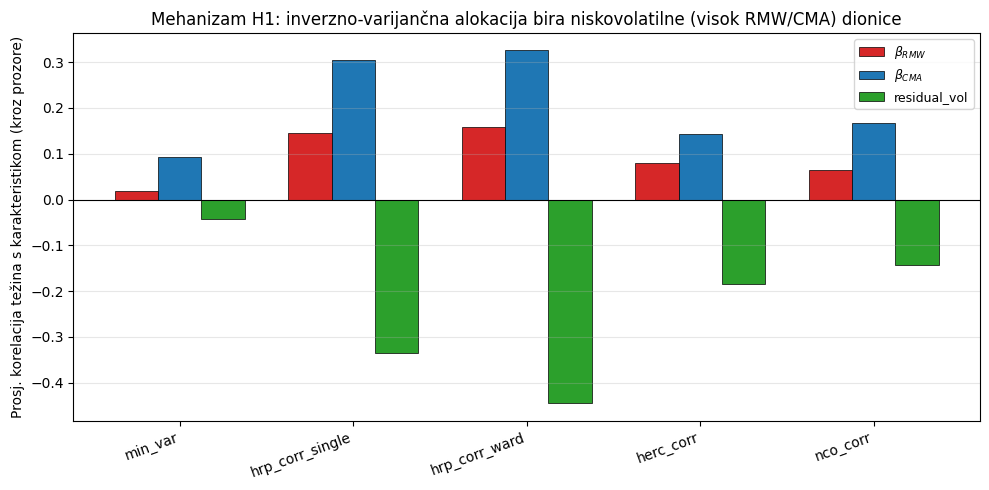

In [7]:
pivot = (
    weight_char_corr.pivot(index="portfolio", columns="characteristic", values="mean_corr")
    .reindex(mech_allocators)
)
colors = {"beta_rmw": "#d62728", "beta_cma": "#1f77b4", "residual_vol": "#2ca02c"}
labels = {
    "beta_rmw": r"$\beta_{RMW}$",
    "beta_cma": r"$\beta_{CMA}$",
    "residual_vol": "residual_vol",
}
x = np.arange(len(pivot.index))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, char in enumerate(CHARACTERISTICS):
    ax.bar(
        x + (i - 1) * width, pivot[char], width,
        label=labels[char], color=colors[char], edgecolor="black", linewidth=0.5,
    )
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=20, ha="right")
ax.set_ylabel("Prosj. korelacija težina s karakteristikom (kroz prozore)")
ax.set_title(
    "Mehanizam H1: inverzno-varijančna alokacija bira niskovolatilne (visok RMW/CMA) dionice"
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_weight_vs_beta.png", dpi=150)
plt.show()


**Čitanje.** Sva tri hijerarhijska alokatora (i `min_var`) imaju **negativnu**
korelaciju težina s `residual_vol` (od −0,14 za NCO do −0,44 za HRP-ward) — dakle
preferiraju niskovolatilne dionice — i **pozitivnu** korelaciju s `beta_rmw` i
`beta_cma`. Mehanizam je najjači kod HRP-a (čista rekurzivna inverzno-varijančna
bisekcija), a kod NCO-a se kanalizira kroz eksplicitni min-var unutar/među
klasterima, zbog čega NCO najvjernije reproducira min-var krajnju točku.


## 10.4 F2.4 — Glavna isporuka: skrivene stilske izloženosti

Konsolidirana tablica (alokator × {β_RMW, β_CMA, koncentracija stila [95 % CI],
ann_vol}) — ekvivalent README tablice starog projekta, sada za hijerarhijske
alokatore, s `min_var` i 1/N kao benchmarcima. Figura prikazuje koncentraciju
stila po testnoj godini.


In [8]:
attr_idx = attribution_full.set_index("portfolio")
ci_idx = bootstrap_ci.set_index("portfolio")
table_order = ["equal_weight", "min_var"] + HIERARCHICAL

rows = []
for name in table_order:
    rows.append(
        {
            "portfolio": name,
            "beta_rmw": float(attr_idx.loc[name, "beta_rmw"]),
            "beta_cma": float(attr_idx.loc[name, "beta_cma"]),
            "style_concentration": float(attr_idx.loc[name, "style_concentration"]),
            "style_conc_ci_low": float(ci_idx.loc[name, "ci_low"]),
            "style_conc_ci_high": float(ci_idx.loc[name, "ci_high"]),
            "ann_vol": annualized_vol(combined[name]),
        }
    )
hidden_style = pd.DataFrame(rows)
hidden_style.to_csv(TABLES_DIR / "10_hidden_style_exposures.csv", index=False)
print(hidden_style.round(4).to_string(index=False))


      portfolio  beta_rmw  beta_cma  style_concentration  style_conc_ci_low  style_conc_ci_high  ann_vol
   equal_weight    0.1699    0.0742               0.5948             0.4537              0.7215   0.1559
        min_var    0.2763    0.3879               0.7761             0.4915              1.3410   0.1270
hrp_corr_single    0.2395    0.1801               0.5493             0.3758              0.8330   0.1360
  hrp_corr_ward    0.2521    0.1775               0.5683             0.4106              0.8131   0.1353
      herc_corr    0.2348    0.2545               0.5739             0.4055              1.2082   0.1431
       nco_corr    0.3170    0.3749               0.7982             0.6273              1.2808   0.1234


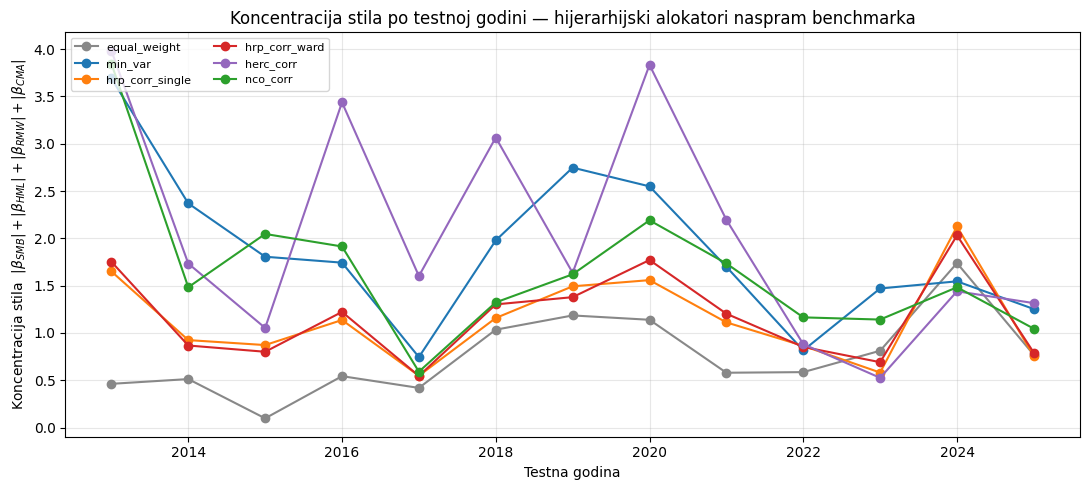

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_order = ["equal_weight", "min_var"] + HIERARCHICAL
palette = {
    "equal_weight": "#888888",
    "min_var": "#1f77b4",
    "hrp_corr_single": "#ff7f0e",
    "hrp_corr_ward": "#d62728",
    "herc_corr": "#9467bd",
    "nco_corr": "#2ca02c",
}
for name in plot_order:
    grp = attribution_per_year[attribution_per_year["portfolio"] == name]
    if grp.empty:
        continue
    ax.plot(
        grp["test_year"], grp["style_concentration"],
        marker="o", linewidth=1.5, color=palette[name], label=name,
    )
ax.set_xlabel("Testna godina")
ax.set_ylabel(
    r"Koncentracija stila  $|\beta_{SMB}|+|\beta_{HML}|+|\beta_{RMW}|+|\beta_{CMA}|$"
)
ax.set_title("Koncentracija stila po testnoj godini — hijerarhijski alokatori naspram benchmarka")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_style_concentration_per_year.png", dpi=150)
plt.show()


## 10.5 Zaključak o H1 (kvantificiran)

**H1:** korelacijski HRP/HERC/NCO nasljeđuju skriveni RMW/CMA nagib min-vara.
Brojevi su iz tablica gore (puni OOS uzorak 2013.–2025., n = 156; CI = 95 %
blok-bootstrap, 1000 uzoraka, blok 12, sjeme 42).

**Mjereni nagibi (β_RMW / β_CMA / koncentracija stila):**

| Alokator | β_RMW | β_CMA | konc. stila |
|---|---|---|---|
| 1/N (`equal_weight`) | 0,17 | 0,07 | 0,59 |
| `min_var` | 0,28 | 0,39 | 0,78 |
| `hrp_corr_single` | 0,24 | 0,18 | 0,55 |
| `hrp_corr_ward` | 0,25 | 0,18 | 0,57 |
| `herc_corr` | 0,23 | 0,25 | 0,57 |
| `nco_corr` | 0,32 | 0,37 | 0,80 |

**Zaključak: H1 je POTVRĐENA za NCO i DJELOMIČNO POTVRĐENA za HRP/HERC.**

1. **RMW nagib nasljeđuju sva četiri alokatora.** β_RMW ∈ [0,23; 0,32] — svi su
   znatno iznad 1/N (0,17) i u smjeru min-vara (0,28); NCO ga čak premašuje
   (0,32). To je jezgra H1: inverzno-varijančna alokacija povlači profitabilne
   (visok RMW) niskovolatilne dionice.

2. **CMA nagib u cijelosti nasljeđuje samo NCO** (β_CMA = 0,37 ≈ min_var 0,39);
   HRP/HERC nose razrijeđen CMA nagib (0,18–0,25) — iznad 1/N (0,07), ali ispod
   min-vara.

3. **Ukupna koncentracija stila:** `nco_corr` (0,80) statistički je nerazlučiv od
   `min_var` (0,78): parna razlika +0,02, CI [−0,15; +0,21], p ≈ 0,64, **i**
   značajno iznad 1/N (+0,20, CI [+0,01; +0,70], p ≈ 0,04). Za NCO je H1 u
   cijelosti potvrđena. HRP/HERC sjede na **razini 1/N** (0,55–0,57): razlika
   naspram 1/N je ≈ 0 (p ≥ 0,52). Naspram min-vara točke su negativne
   (−0,20 do −0,23), ali je značajnost rubna i nejednolika — `hrp_corr_single`
   p ≈ 0,05, `hrp_corr_ward` p ≈ 0,09, dok `herc_corr` ima širok CI (p ≈ 0,52).
   Za HRP/HERC je H1 potvrđena u **RMW komponenti**, ali ne u ukupnoj
   koncentraciji stila — ona ostaje na razini 1/N, ne min-vara.

4. **Mehanizam potvrđen (10.3):** svi alokatori biraju niskovolatilne dionice
   (korelacija težina s `residual_vol` od −0,14 do −0,44), koje nose pozitivne
   RMW/CMA izloženosti (korelacija težina s β_RMW +0,07…+0,16; s β_CMA
   +0,14…+0,33) — upravo mehanizam Scherera (2011) i Novy-Marxa (2014).

**Cijena volatilnosti.** Anualizirana volatilnost NCO-a i HRP-a ne razlikuje se
značajno od min-vara (NCO −0,4 p.b., p ≈ 0,08; HRP +0,8–0,9 p.b., p ≈ 0,08–0,12);
`herc_corr` ima nešto višu vol (+1,6 p.b., p ≈ 0,01). NCO tako reproducira skriveni
stilski nagib min-vara **bez ostvarene cijene volatilnosti** (`10_paired_diffs_vs_minvar.csv`,
metrika `annualized_vol`) — nagib je *skriven*, ne kompenziran rizikom. Time je
postavljena pozornica za Fazu 3 (mijenja li **prostor** hijerarhije nagib, H2) i
Fazu 4 (uklanja li ga tek izravni overlay na bete, H3).
